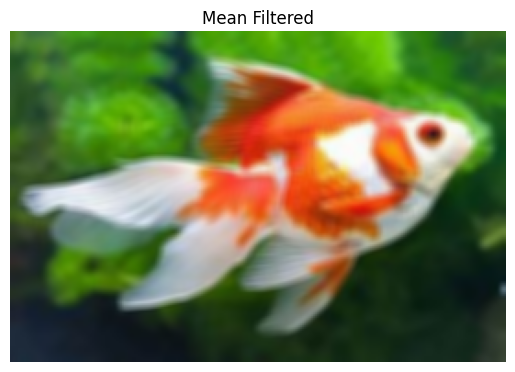

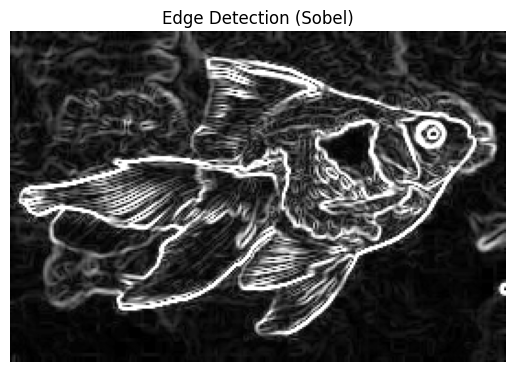

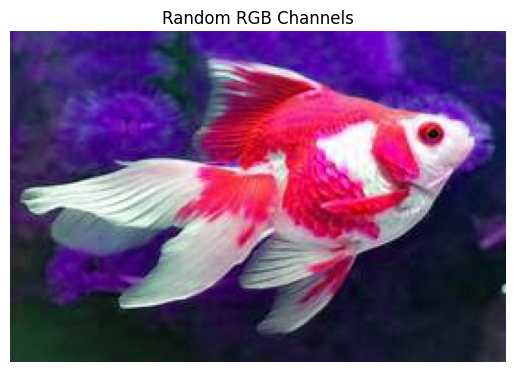

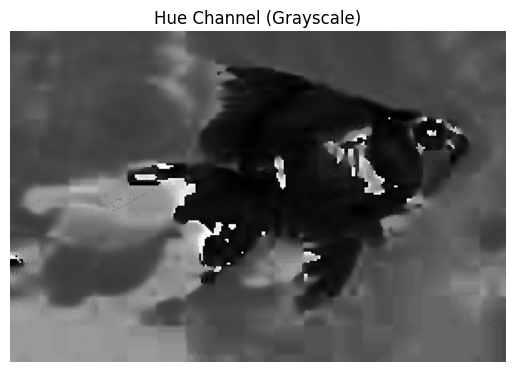

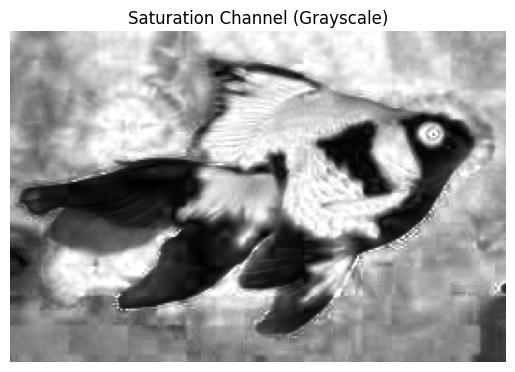

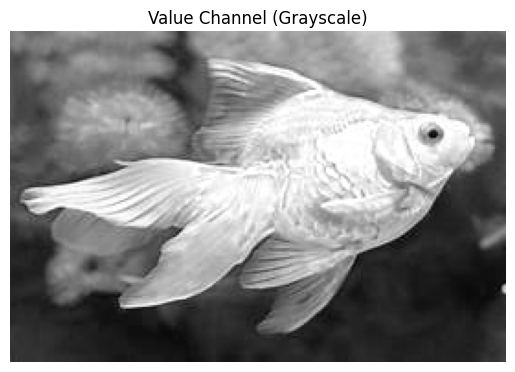

In [1]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

# Hàm hiển thị ảnh bằng matplotlib
def show_image(img, title=''):
    if len(img.shape) == 2:  # Ảnh grayscale
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

# Đọc ảnh
img = cv2.imread('a.jpg')
if img is None:
    print("Không tìm thấy ảnh a.jpg")
    exit()

# 1. Mean filter
mean = cv2.blur(img, (5, 5))
cv2.imwrite('a_mean.jpg', mean)
show_image(mean, 'Mean Filtered')

# 2. Edge detection (Sobel)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobelx, sobely)
sobel = np.uint8(np.clip(sobel, 0, 255))
cv2.imwrite('a_sobel.jpg', sobel)
show_image(sobel, 'Edge Detection (Sobel)')

# 3. Đổi kênh màu RGB ngẫu nhiên
b, g, r = cv2.split(img)
channels = [b, g, r]
random.shuffle(channels)
swapped = cv2.merge(channels)
cv2.imwrite('a_random_color.jpg', swapped)
show_image(swapped, 'Random RGB Channels')

# 4. Chuyển HSV và tách các kênh
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
cv2.imwrite('a_hue.jpg', h)
cv2.imwrite('a_saturation.jpg', s)
cv2.imwrite('a_value.jpg', v)

show_image(h, 'Hue Channel (Grayscale)')
show_image(s, 'Saturation Channel (Grayscale)')
show_image(v, 'Value Channel (Grayscale)')




Chọn phím để thực hiện biến đổi:
I - Image inverse transformation
G - Gamma-Correction
L - Log Transformation
H - Histogram Equalization
C - Contrast Stretching
A - Adaptive Histogram Equalization (CLAHE)
> Contrast Stretching: min=7, max=222 cho ảnh 1
 Đã lưu ảnh: output_contrast_1.jpg


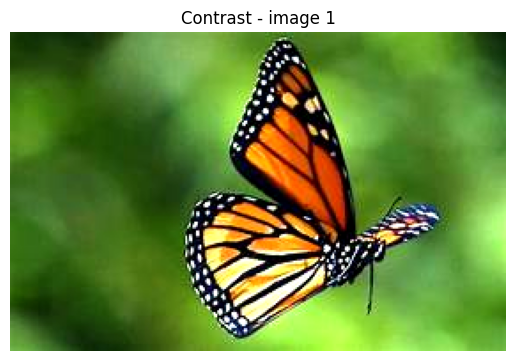

> Contrast Stretching: min=0, max=253 cho ảnh 2
 Đã lưu ảnh: output_contrast_2.jpg


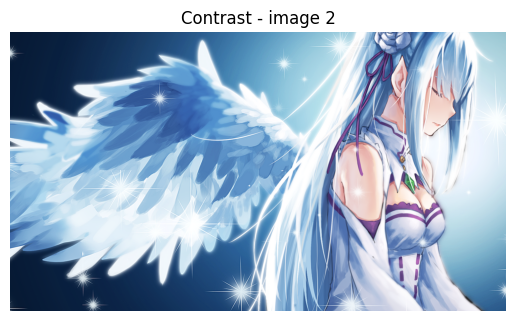

> Contrast Stretching: min=19, max=214 cho ảnh 3
 Đã lưu ảnh: output_contrast_3.jpg


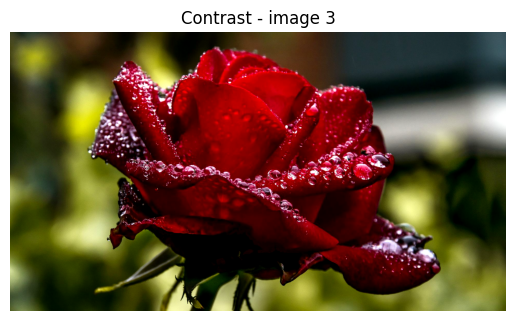

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import os

# Đọc 3 ảnh
image_files = ['image1.jpg', 'image2.jpg', 'image3.jpg']
images = []
for file in image_files:
    if not os.path.exists(file):
        print(f" Không tìm thấy file {file}")
        images.append(None)
    else:
        images.append(cv2.imread(file))

# Hiển thị menu
print("Chọn phím để thực hiện biến đổi:")
print("I - Image inverse transformation")
print("G - Gamma-Correction")
print("L - Log Transformation")
print("H - Histogram Equalization")
print("C - Contrast Stretching")
print("A - Adaptive Histogram Equalization (CLAHE)")

key = input("Nhập phím lựa chọn: ").upper()

# Hàm hiển thị ảnh
def show_image(img, title=''):
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

# Các hàm xử lý
def inverse(img):
    return 255 - img

def gamma_correction(img, gamma):
    invGamma = 1.0 / gamma
    table = np.array([(i / 255.0) ** invGamma * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(img, table)

def log_transform(img, c):
    img_float = img.astype(np.float32)
    result = c * np.log1p(img_float)
    return np.uint8(np.clip(result, 0, 255))

def histogram_equalization(img):
    if len(img.shape) == 2:
        return cv2.equalizeHist(img)
    else:
        ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
        ycrcb[:, :, 0] = cv2.equalizeHist(ycrcb[:, :, 0])
        return cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)

def contrast_stretching(img, min_val, max_val):
    img_float = img.astype(np.float32)
    stretched = 255 * (img_float - min_val) / (max_val - min_val)
    return np.uint8(np.clip(stretched, 0, 255))

def adaptive_hist_eq(img):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    result = clahe.apply(gray)
    return result

# Thực hiện theo phím nhấn
for idx, img in enumerate(images):
    if img is None:
        continue
    output = None
    name = ""

    if key == 'I':
        output = inverse(img)
        name = 'inverse'

    elif key == 'G':
        gamma = round(random.uniform(0.5, 2.0), 2)
        print(f"> Gamma = {gamma} cho ảnh {idx+1}")
        output = gamma_correction(img, gamma)
        name = 'gamma'

    elif key == 'L':
        c = round(random.uniform(1.0, 5.0), 2)
        print(f"> C (log factor) = {c} cho ảnh {idx+1}")
        output = log_transform(img, c)
        name = 'log'

    elif key == 'H':
        output = histogram_equalization(img)
        name = 'histogram'

    elif key == 'C':
        min_val = random.randint(0, 50)
        max_val = random.randint(200, 255)
        print(f"> Contrast Stretching: min={min_val}, max={max_val} cho ảnh {idx+1}")
        output = contrast_stretching(img, min_val, max_val)
        name = 'contrast'

    elif key == 'A':
        output = adaptive_hist_eq(img)
        name = 'adaptive'

    else:
        print(" Phím không hợp lệ.")
        break

    filename = f"output_{name}_{idx+1}.jpg"
    cv2.imwrite(filename, output)
    print(f" Đã lưu ảnh: {filename}")
    show_image(output, f"{name.capitalize()} - image {idx+1}")


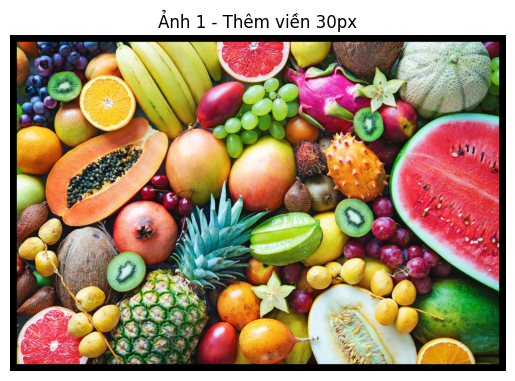

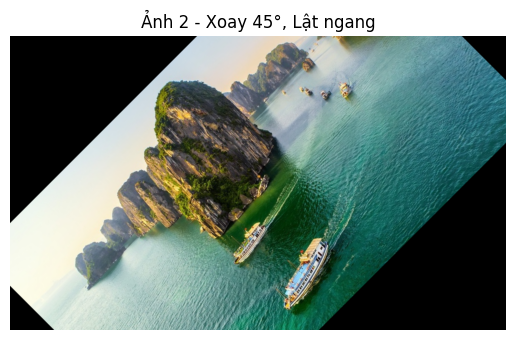

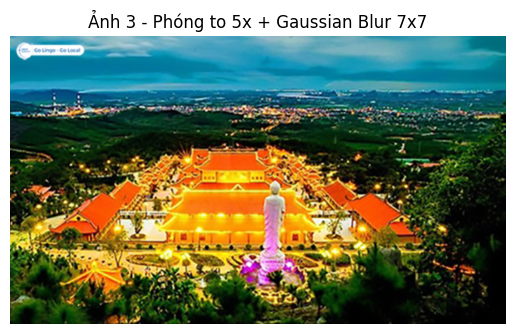

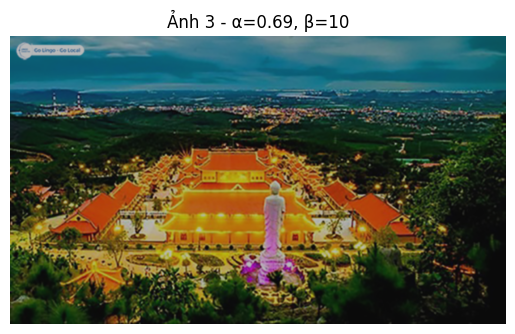

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# Đọc ảnh
img1 = cv2.imread('colorful-ripe-tropical-fruits.jpg')
img2 = cv2.imread('quang_ninh.jpg')
img3 = cv2.imread('pagoda.jpg')

# Kiểm tra ảnh có tồn tại
if img1 is None or img2 is None or img3 is None:
    print("Một trong các ảnh không tồn tại. Vui lòng kiểm tra tên file.")
    exit()

# ----------- 1. Tăng kích thước ảnh thứ nhất thêm 30px  ------------
img1_border = cv2.copyMakeBorder(img1, 30, 30, 30, 30, cv2.BORDER_CONSTANT, value=(0, 0, 0))
cv2.imwrite('output_fruit_border.jpg', img1_border)
plt.imshow(cv2.cvtColor(img1_border, cv2.COLOR_BGR2RGB))
plt.title("Ảnh 1 - Thêm viền 30px")
plt.axis('off')
plt.show()

# ----------- 2. Xoay ảnh thứ hai 45 độ theo chiều kim đồng hồ và lật ngang ------------
(h, w) = img2.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, -45, 1.0)  # -45 độ = xoay 45 độ theo kim đồng hồ
rotated = cv2.warpAffine(img2, M, (w, h))
flipped = cv2.flip(rotated, 1)
cv2.imwrite('output_quangninh_rotated_flipped.jpg', flipped)
plt.imshow(cv2.cvtColor(flipped, cv2.COLOR_BGR2RGB))
plt.title("Ảnh 2 - Xoay 45°, Lật ngang")
plt.axis('off')
plt.show()

# ----------- 3. Phóng to ảnh 3 lên 5 lần và làm mịn bằng Gaussian blur 7x7 ------------
resized = cv2.resize(img3, None, fx=5, fy=5, interpolation=cv2.INTER_LINEAR)
blurred = cv2.GaussianBlur(resized, (7, 7), 0)
cv2.imwrite('output_pagoda_blurred.jpg', blurred)
plt.imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
plt.title("Ảnh 3 - Phóng to 5x + Gaussian Blur 7x7")
plt.axis('off')
plt.show()

# ----------- 4. Điều chỉnh sáng và tương phản ảnh thứ 3 ------------

# Tạo bản sao ảnh đã phóng to để áp dụng công thức
adjusted_img = blurred.astype(np.float32)

# Chọn alpha và beta ngẫu nhiên trong khoảng cho phép
alpha = round(random.uniform(0.5, 2.0), 2)
beta = random.randint(-50, 50)

# Áp dụng công thức: Iout(x,y) = α * Iin(x,y) + β
adjusted_img = alpha * adjusted_img + beta

# Giới hạn giá trị [0, 255] và chuyển về kiểu uint8
adjusted_img = np.clip(adjusted_img, 0, 255).astype(np.uint8)

# Lưu và hiển thị kết quả
cv2.imwrite('output_pagoda_brightness_contrast.jpg', adjusted_img)
plt.imshow(cv2.cvtColor(adjusted_img, cv2.COLOR_BGR2RGB))
plt.title(f"Ảnh 3 - α={alpha}, β={beta}")
plt.axis('off')
plt.show()
